In [8]:
import math

from qiskit import QuantumCircuit
from qiskit.circuit.library import MCMTGate, MCMT, XGate, ZGate
from qiskit.circuit.library import grover_operator
from qiskit.visualization import plot_distribution

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

As an example, let's construct oracle which would be finding state 1001:

In [18]:
oracle = QuantumCircuit(4, name="oracle")
oracle.x(2)
oracle.x(1)
oracle.compose(MCMTGate(ZGate(), 3, 1, ctrl_state=None, label=None), inplace=True)

oracle.x(2)
oracle.x(1)

oracle.draw()

1-Z      
q_0: ───────■───────
     ┌───┐  │  ┌───┐
q_1: ┤ X ├──■──┤ X ├
     ├───┤  │  ├───┤
q_2: ┤ X ├──■──┤ X ├
     └───┘  │  └───┘
q_3: ───────■───────

Let's see how this oracle works by applying it to the state we look for and some other state.
We look for state 1001, so let's start with it first:

In [3]:
from qiskit.quantum_info import Statevector

state = Statevector.from_label('1001')
state = state.evolve(oracle)
state.draw('latex')

<IPython.core.display.Latex object>

It was correctly multiplied by -1. - as we need.
Now let's show that it leaves other states untached, let's use 1011 as an example, but you can experiment with any state:

In [4]:
state = Statevector.from_label('1011')
state = state.evolve(oracle)
state.draw('latex')

<IPython.core.display.Latex object>

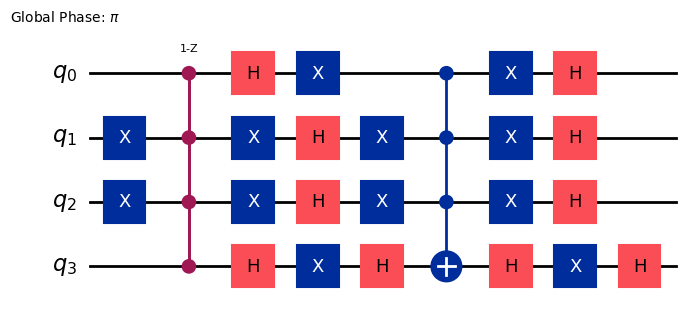

In [10]:
grover_op = grover_operator(oracle)
grover_op.draw(output="mpl", style="iqp")

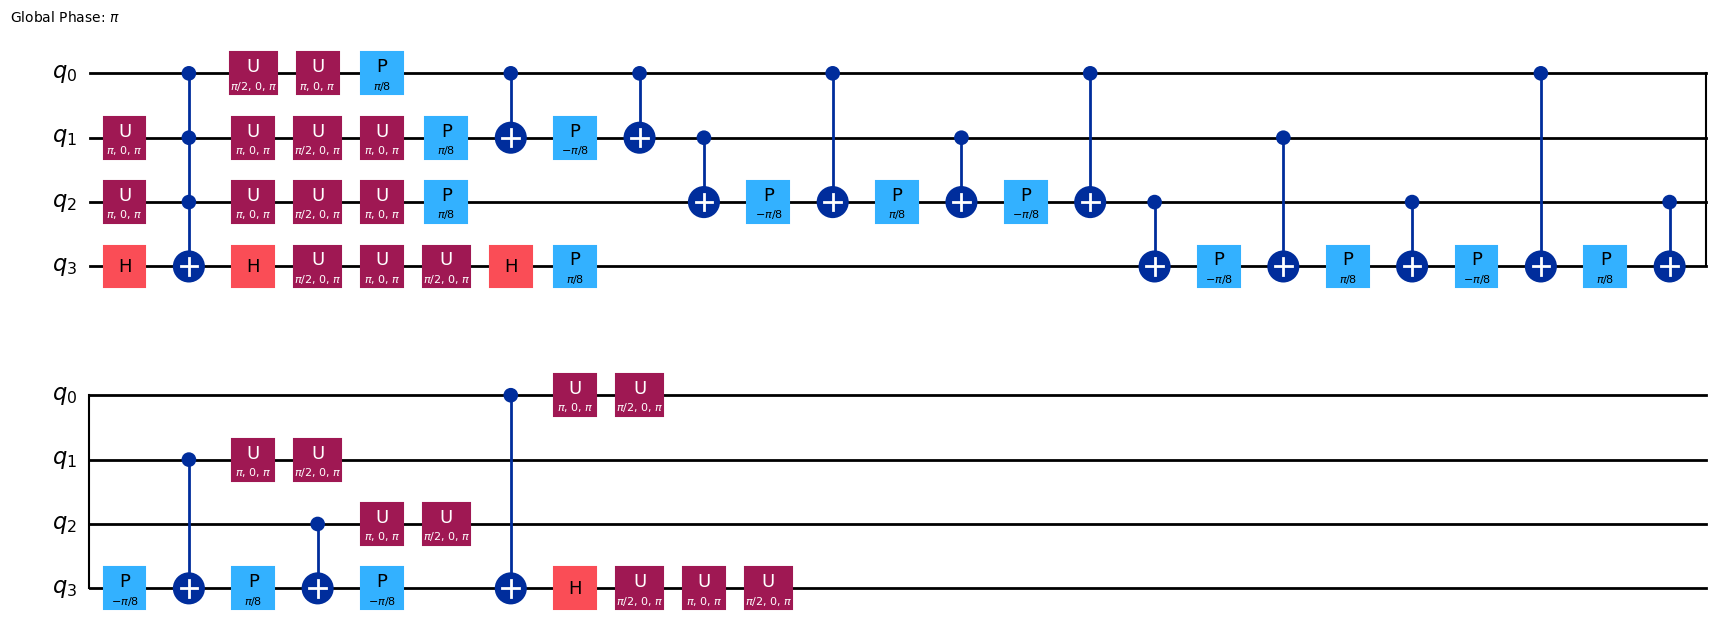

In [11]:
grover_op.decompose().draw(output="mpl", style="iqp")

In [13]:
optimal_num_iterations = math.floor(math.pi / (4 * math.asin(math.sqrt(1 / 2**grover_op.num_qubits))))
print(optimal_num_iterations)

3


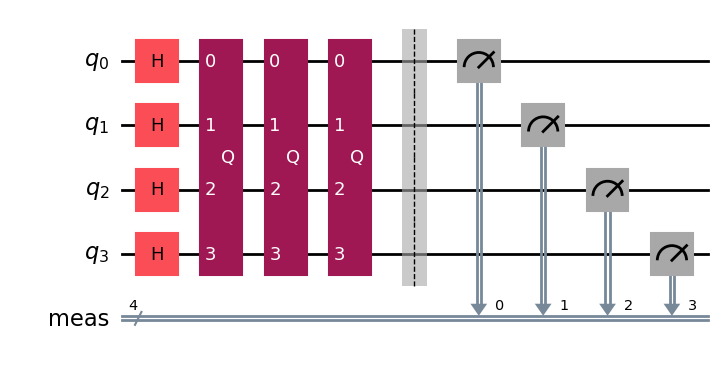

In [14]:
qc = QuantumCircuit(grover_op.num_qubits)
qc.h(range(grover_op.num_qubits))
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)
qc.measure_all()
qc.draw(output="mpl", style="iqp")

In [17]:
from qiskit.primitives import StatevectorSampler

sampler_simulator = StatevectorSampler()

num_shots = 1000000
result = sampler_simulator.run([qc], shots=num_shots).result()
data_pub = result[0].data
counts = data_pub.meas.get_counts()

for i in counts:
    counts[i] = float(counts[i]/num_shots)

print(f"The probabilities are: {counts}")

The probabilities are: {'1001': 0.961446, '0111': 0.002574, '1011': 0.002613, '0001': 0.002588, '0110': 0.002468, '0101': 0.002552, '1101': 0.002455, '0010': 0.002552, '0100': 0.002594, '1000': 0.002533, '1110': 0.002573, '1100': 0.002593, '0011': 0.002666, '0000': 0.002584, '1010': 0.002658, '1111': 0.002551}


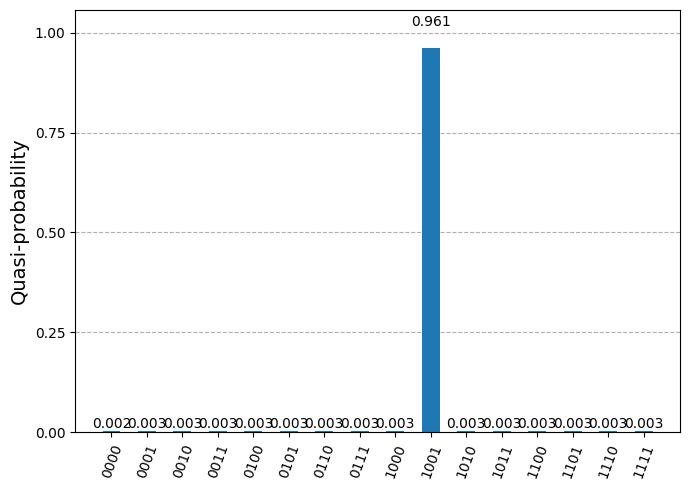

In [32]:
plot_distribution(counts)

# Exercise 1
Play with number of Grover operator iterations. Go from 1 to 6 iterations. Explain the results.

# Exercise 2
Implement Grover's algorithm looking for 4 bit bitstring with a given hash (also 4 bit long).
We look for a bitstring for which hash is `1100` and the definition of hash is:
```
h0 = x0 XOR x1
h1 = x1 XOR x2
h2 = x2 XOR x3
h3 = x3 XOR x0
```
where x0, x1, x2 and x3 and subsequent bits of the bit string from which hash is calculated.

Hints:
* implementing oracle on 'main register' ($\ket{x}$) is often hard, so we use ancilla qubits
* you can implement oracle by computing f(x) on ancilla qubit, then apply Z gate on it if we have proper state (multiple-controlled z gate) and then uncomputing f(x) (applying reverse set of gates than computing f(x))
* in our case we can use 9 qubits in oracle on which you will:
  * 1-4 encode $\ket{x}$
  * 5-8 calculate hash from $\ket{x}$
  * 9 final qubit to calculate f(x) ('mark' the proper state) - this is target qubit for the multi-controlled z gate

# Exercise 3
Implement Grover search on real backend, but with 3 qubits, looking for state |110>. Optimize for proper state amplification.

# Exercise 4
Implement Grover algorithm on simulator which would amplify state |00111>.